# 静态场景 - 密度扫描实验
固定业务比例，扫描不同总密度下的性能表现

## 初始化环境

In [2]:
import sys
sys.path.insert(0, '.')

from algo.logger import reset_logger
reset_logger()

In [3]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]

# 导入评估工具（包括static_sensitivity_config和load_yaml_config）
from utils.evaluate import (
    static_sensitivity_config,
    train_and_evaluate_scenario,
    print_results_summary,
    load_yaml_config
)
import baseline
importlib.reload(baseline)
from baseline import run_episode


## 密度扫描配置生成

In [4]:
def run_density_sweep_experiment():
    """
    密度扫描实验：固定业务比例，扫描总密度
    用于绘制：Throughput vs. Density 曲线
    """
    # 1. 定义几个固定的业务混合模式
    traffic_mixes = {
        "HO_Interference_Heavy": {'cbra': 0.2, 'pbra': 0.1, 'cfra': 0.7},
    }

    # 2. 定义要扫描的密度范围
    densities = [5.0, 10.0, 15, 20.0]
    configs = []

    print("--- Generating Density Sweep Configs ---")
    for mix_name, ratios in traffic_mixes.items():
        for d in densities:
            cfg = static_sensitivity_config(
                total_density=d,
                cbra_ratio=ratios['cbra'],
                pbra_ratio=ratios['pbra'],
                cfra_ratio=ratios['cfra']
            )
            label = f"{mix_name}_D{int(d)}"
            configs.append((label, cfg))
            print(f"Generated: [{label}]")

    return configs

# 生成配置
density_sweep_configs = run_density_sweep_experiment()
print(f"\n总共生成 {len(density_sweep_configs)} 个密度扫描场景配置")

--- Generating Density Sweep Configs ---
Generated: [HO_Interference_Heavy_D5]
Generated: [HO_Interference_Heavy_D10]
Generated: [HO_Interference_Heavy_D15]
Generated: [HO_Interference_Heavy_D20]

总共生成 4 个密度扫描场景配置


## 加载训练配置

In [5]:
CONFIG_PATH = Path("conf/default.yaml")

raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)

log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_density_sweep_HO.log"
try:
    os.remove(log_file) if os.path.exists(log_file) else None
except Exception as e:
    print(f"Warning: Could not remove existing log file: {e}")

log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized for density sweep experiment")

# 环境配置
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)

simulator_config = default_simulator_config()
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=10,
    decision_horizon=100,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)

num_envs = 8
env_backend = "parallel"

train_config = HPPOConfig(
    frames_per_batch=3200,
    mini_batch_size=256,
    rollout_epochs=4,
    max_iterations=500,  # 静态场景训练100轮
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,
    entropy_coeff=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    device=torch.device(algo_section.get("device", "cpu")),
)

my_logger.info(f"Config ready | seed={seed} num_envs={num_envs}")
print(f"配置加载完成: {len(density_sweep_configs)} 个场景待训练")


Loaded configuration from conf\default.yaml
配置加载完成: 4 个场景待训练


2025-12-03 22:24:44 | INFO     | Logger initialized for density sweep experiment
2025-12-03 22:24:44 | INFO     | Config ready | seed=42 num_envs=8
2025-12-03 22:24:44 | INFO     | Config ready | seed=42 num_envs=8


## 执行密度扫描训练

In [6]:
# 全局结果存储
all_scenarios_results = OrderedDict()

print(f"\n{'='*80}")
print(f"开始批量训练 {len(density_sweep_configs)} 个密度扫描场景")
print(f"{'='*80}\n")

for idx, (label, sim_config) in enumerate(density_sweep_configs):
    print(f"\n[{idx+1}/{len(density_sweep_configs)}] 当前场景: {label}")
    try:
        result = train_and_evaluate_scenario(
            scenario_name=label,
            sim_config=sim_config,
            env_config=env_config,
            train_config=train_config,
            build_env_func=build_gym_env,
            build_modules_func=build_hppo_modules,
            train_func=train_hppo,
            run_episode_func=run_episode,
            logger=my_logger,
            num_envs=num_envs,
            env_backend=env_backend,
            num_episodes=20,
            seed=seed
        )
        all_scenarios_results[label] = result
    except Exception as e:
        print(f"场景 {label} 训练失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景训练完成!")
print(f"成功训练场景数: {len(all_scenarios_results)}/{len(density_sweep_configs)}")
print(f"{'='*80}")

# 显示结果摘要
print_results_summary(all_scenarios_results)


开始批量训练 4 个密度扫描场景


[1/4] 当前场景: HO_Interference_Heavy_D5

开始训练场景: HO_Interference_Heavy_D5
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.2_P0.1_F0.7', cbra_density=1.0, pbra_density=0.5, cfra_density=3.5),), segments=(RegionSegment(region_name='static_D5.0_C0.2_P0.1_F0.7', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-03 22:24:44,920 [torchrl][INFO]    The info_dict_reader does

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-03 22:24:49 | INFO     | Starting PPO training for scenario: HO_Interference_Heavy_D5


  iter=0000, reward=-3.8825
  iter=0010, reward=0.1364
  iter=0010, reward=0.1364
  iter=0020, reward=0.3051
  iter=0020, reward=0.3051
  iter=0030, reward=0.4663
  iter=0030, reward=0.4663
  iter=0040, reward=0.5972
  iter=0040, reward=0.5972
  iter=0050, reward=0.7076
  iter=0050, reward=0.7076
  iter=0060, reward=0.7815
  iter=0060, reward=0.7815
  iter=0070, reward=0.8020
  iter=0070, reward=0.8020
  iter=0080, reward=0.8344
  iter=0080, reward=0.8344
  iter=0090, reward=0.8255
  iter=0090, reward=0.8255
  iter=0100, reward=0.8862
  iter=0100, reward=0.8862
  iter=0110, reward=0.9109
  iter=0110, reward=0.9109
  iter=0120, reward=0.9912
  iter=0120, reward=0.9912
  iter=0130, reward=1.0826
  iter=0130, reward=1.0826
  iter=0140, reward=1.0716
  iter=0140, reward=1.0716
  iter=0150, reward=1.0982
  iter=0150, reward=1.0982
  iter=0160, reward=1.0543
  iter=0160, reward=1.0543
  iter=0170, reward=1.0677
  iter=0170, reward=1.0677
  iter=0180, reward=1.1296
  iter=0180, reward=1.1296


2025-12-03 23:26:37 | INFO     | Starting PPO training for scenario: HO_Interference_Heavy_D10


  iter=0000, reward=-0.4601
  iter=0010, reward=0.4028
  iter=0010, reward=0.4028
  iter=0020, reward=0.7161
  iter=0020, reward=0.7161
  iter=0030, reward=0.7639
  iter=0030, reward=0.7639
  iter=0040, reward=0.9573
  iter=0040, reward=0.9573
  iter=0050, reward=1.0325
  iter=0050, reward=1.0325
  iter=0060, reward=1.1334
  iter=0060, reward=1.1334
  iter=0070, reward=1.0888
  iter=0070, reward=1.0888
  iter=0080, reward=1.1797
  iter=0080, reward=1.1797
  iter=0090, reward=1.2693
  iter=0090, reward=1.2693
  iter=0100, reward=1.2705
  iter=0100, reward=1.2705
  iter=0110, reward=1.3241
  iter=0110, reward=1.3241
  iter=0120, reward=1.3422
  iter=0120, reward=1.3422
  iter=0130, reward=1.2946
  iter=0130, reward=1.2946
  iter=0140, reward=1.3710
  iter=0140, reward=1.3710
  iter=0150, reward=1.3922
  iter=0150, reward=1.3922
  iter=0160, reward=1.4222
  iter=0160, reward=1.4222
  iter=0170, reward=1.4467
  iter=0170, reward=1.4467
  iter=0180, reward=1.3892
  iter=0180, reward=1.3892


2025-12-04 01:57:45 | INFO     | Starting PPO training for scenario: HO_Interference_Heavy_D15


  iter=0000, reward=-1.8392
  iter=0010, reward=0.0582
  iter=0010, reward=0.0582
  iter=0020, reward=0.6814
  iter=0020, reward=0.6814
  iter=0030, reward=0.9062
  iter=0030, reward=0.9062
  iter=0040, reward=1.0060
  iter=0040, reward=1.0060
  iter=0050, reward=1.1296
  iter=0050, reward=1.1296
  iter=0060, reward=1.1867
  iter=0060, reward=1.1867
  iter=0070, reward=1.2734
  iter=0070, reward=1.2734
  iter=0080, reward=1.2808
  iter=0080, reward=1.2808
  iter=0090, reward=1.3399
  iter=0090, reward=1.3399
  iter=0100, reward=1.4158
  iter=0100, reward=1.4158
  iter=0110, reward=1.4270
  iter=0110, reward=1.4270
  iter=0120, reward=1.3948
  iter=0120, reward=1.3948
  iter=0130, reward=1.4516
  iter=0130, reward=1.4516
  iter=0140, reward=0.8158
  iter=0140, reward=0.8158
  iter=0150, reward=1.2997
  iter=0150, reward=1.2997
  iter=0160, reward=1.4203
  iter=0160, reward=1.4203
  iter=0170, reward=1.5083
  iter=0170, reward=1.5083
  iter=0180, reward=1.5230
  iter=0180, reward=1.5230


2025-12-04 04:28:03 | INFO     | Starting PPO training for scenario: HO_Interference_Heavy_D20


  iter=0000, reward=-4.4428
  iter=0010, reward=-0.5767
  iter=0010, reward=-0.5767
  iter=0020, reward=-0.1739
  iter=0020, reward=-0.1739
  iter=0030, reward=0.3661
  iter=0030, reward=0.3661
  iter=0040, reward=0.5909
  iter=0040, reward=0.5909
  iter=0050, reward=0.6968
  iter=0050, reward=0.6968
  iter=0060, reward=0.8581
  iter=0060, reward=0.8581
  iter=0070, reward=1.0912
  iter=0070, reward=1.0912
  iter=0080, reward=1.1136
  iter=0080, reward=1.1136
  iter=0090, reward=1.1764
  iter=0090, reward=1.1764
  iter=0100, reward=1.2680
  iter=0100, reward=1.2680
  iter=0110, reward=1.2960
  iter=0110, reward=1.2960
  iter=0120, reward=1.3715
  iter=0120, reward=1.3715
  iter=0130, reward=1.4152
  iter=0130, reward=1.4152
  iter=0140, reward=1.4901
  iter=0140, reward=1.4901
  iter=0150, reward=1.4611
  iter=0150, reward=1.4611
  iter=0160, reward=1.5113
  iter=0160, reward=1.5113
  iter=0170, reward=1.5207
  iter=0170, reward=1.5207
  iter=0180, reward=1.5132
  iter=0180, reward=1.5

## 可视化密度扫描结果

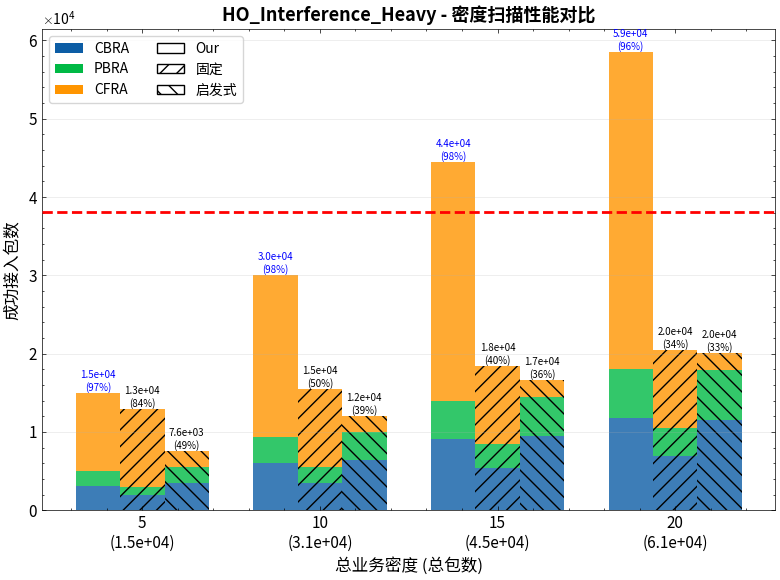

密度扫描对比图已保存到: output/static/density_sweep_HO.svg


In [7]:
def plot_density_sweep_results():
    """绘制密度扫描实验结果 - 单个流量模式的图"""
    traffic_mixes = ["HO_Interference_Heavy"]
    densities = [5.0, 10.0, 15.0, 20.0]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    for mix_idx, mix_name in enumerate(traffic_mixes):
        # 收集数据
        ppo_cbra = []
        ppo_pbra = []
        ppo_cfra = []
        ppo_theo = []
        fixed_cbra = []
        fixed_pbra = []
        fixed_cfra = []
        fixed_theo = []
        heuristic_cbra = []
        heuristic_pbra = []
        heuristic_cfra = []
        heuristic_theo = []
        total_arrivals_list = []

        for d in densities:
            label = f"{mix_name}_D{int(d)}"
            if label in all_scenarios_results:
                result = all_scenarios_results[label]

                # PPO最佳模型
                ppo_cbra.append(result['eval_results_best']['eval_success_cbra'])
                ppo_pbra.append(result['eval_results_best']['eval_success_pbra'])
                ppo_cfra.append(result['eval_results_best']['eval_success_cfra'])
                ppo_theo.append(result['eval_results_best'].get('eval_theoretical_optimal', 0))

                # 固定分配
                fixed_cbra.append(result['baseline_results']['固定分配']['success_cbra'])
                fixed_pbra.append(result['baseline_results']['固定分配']['success_pbra'])
                fixed_cfra.append(result['baseline_results']['固定分配']['success_cfra'])
                fixed_theo.append(result['baseline_results']['固定分配'].get('theoretical_optimal', 0))

                # 启发式算法
                heuristic_cbra.append(result['baseline_results']['启发式算法']['success_cbra'])
                heuristic_pbra.append(result['baseline_results']['启发式算法']['success_pbra'])
                heuristic_cfra.append(result['baseline_results']['启发式算法']['success_cfra'])
                heuristic_theo.append(result['baseline_results']['启发式算法'].get('theoretical_optimal', 0))

                # 获取总到达包数 (使用固定分配的到达数作为参考)
                total_arr = (result['baseline_results']['固定分配']['arrivals_cbra'] +
                           result['baseline_results']['固定分配']['arrivals_pbra'] +
                           result['baseline_results']['固定分配']['arrivals_cfra'])
                total_arrivals_list.append(total_arr)
            else:
                ppo_cbra.append(0)
                ppo_pbra.append(0)
                ppo_cfra.append(0)
                ppo_theo.append(0)
                fixed_cbra.append(0)
                fixed_pbra.append(0)
                fixed_cfra.append(0)
                fixed_theo.append(0)
                heuristic_cbra.append(0)
                heuristic_pbra.append(0)
                heuristic_cfra.append(0)
                heuristic_theo.append(0)
                total_arrivals_list.append(0)

        ppo_cbra = np.array(ppo_cbra)
        ppo_pbra = np.array(ppo_pbra)
        ppo_cfra = np.array(ppo_cfra)
        ppo_theo = np.array(ppo_theo)
        fixed_cbra = np.array(fixed_cbra)
        fixed_pbra = np.array(fixed_pbra)
        fixed_cfra = np.array(fixed_cfra)
        fixed_theo = np.array(fixed_theo)
        heuristic_cbra = np.array(heuristic_cbra)
        heuristic_pbra = np.array(heuristic_pbra)
        heuristic_cfra = np.array(heuristic_cfra)
        heuristic_theo = np.array(heuristic_theo)

        ppo_total = ppo_cbra + ppo_pbra + ppo_cfra
        fixed_total = fixed_cbra + fixed_pbra + fixed_cfra
        heuristic_total = heuristic_cbra + heuristic_pbra + heuristic_cfra

        # 绘制堆叠柱状图
        x = np.arange(len(densities))
        width = 0.25

        # Our (最佳) - 实心
        p1_cbra = ax.bar(x - width, ppo_cbra, width, alpha=0.8, color='C0')
        p1_pbra = ax.bar(x - width, ppo_pbra, width, bottom=ppo_cbra, alpha=0.8, color='C1')
        p1_cfra = ax.bar(x - width, ppo_cfra, width, bottom=ppo_cbra+ppo_pbra, alpha=0.8, color='C2')

        # 固定分配 - 斜线填充
        p2_cbra = ax.bar(x, fixed_cbra, width, alpha=0.8, color='C0', hatch='//')
        p2_pbra = ax.bar(x, fixed_pbra, width, bottom=fixed_cbra, alpha=0.8, color='C1', hatch='//')
        p2_cfra = ax.bar(x, fixed_cfra, width, bottom=fixed_cbra+fixed_pbra, alpha=0.8, color='C2', hatch='//')

        # 启发式算法 - 反斜线填充
        p3_cbra = ax.bar(x + width, heuristic_cbra, width, alpha=0.8, color='C0', hatch='\\\\')
        p3_pbra = ax.bar(x + width, heuristic_pbra, width, bottom=heuristic_cbra, alpha=0.8, color='C1', hatch='\\\\')
        p3_cfra = ax.bar(x + width, heuristic_cfra, width, bottom=heuristic_cbra+heuristic_pbra, alpha=0.8, color='C2', hatch='\\\\')

        # 添加理论最优值水平线 (使用平均值)
        avg_theo = np.mean([t for t in ppo_theo if t > 0])
        if avg_theo > 0:
            ax.axhline(avg_theo, color='red', linestyle='--', linewidth=2,
                      label=f'理论最优 (平均={int(avg_theo)})', zorder=10)

        # 标注总数和达最优率
        for i in range(len(densities)):
            if ppo_total[i] > 0:
                theo_rate = (ppo_total[i] / ppo_theo[i] * 100) if ppo_theo[i] > 0 else 0
                ax.text(i - width, ppo_total[i], f'{ppo_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7, color='blue')
            if fixed_total[i] > 0:
                theo_rate = (fixed_total[i] / fixed_theo[i] * 100) if fixed_theo[i] > 0 else 0
                ax.text(i, fixed_total[i], f'{fixed_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)
            if heuristic_total[i] > 0:
                theo_rate = (heuristic_total[i] / heuristic_theo[i] * 100) if heuristic_theo[i] > 0 else 0
                ax.text(i + width, heuristic_total[i], f'{heuristic_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)

        ax.set_xlabel('总业务密度 (总包数)', fontsize=12)
        ax.set_ylabel('成功接入包数', fontsize=12)
        ax.set_title(f'{mix_name} - 密度扫描性能对比', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        # 横轴标签添加总包数信息
        xticklabels = [f'{int(d)}\n({int(arr):.1e})' if arr > 0 else f'{int(d)}'
                      for d, arr in zip(densities, total_arrivals_list)]
        ax.set_xticklabels(xticklabels, fontsize=10)

        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='C0', label='CBRA'),
            Patch(facecolor='C1', label='PBRA'),
            Patch(facecolor='C2', label='CFRA'),
            Patch(facecolor='white', edgecolor='black', label='Our'),
            Patch(facecolor='white', edgecolor='black', hatch='//', label='固定'),
            Patch(facecolor='white', edgecolor='black', hatch='\\\\', label='启发式'),
        ]
        ax.legend(handles=legend_elements, fontsize=10, frameon=True, loc='upper left', ncol=2)

        ax.tick_params(labelsize=11)
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs("output/static", exist_ok=True)
    plt.savefig("output/static/density_sweep_HO.svg", bbox_inches='tight', dpi=300)
    plt.show()
    print("密度扫描对比图已保存到: output/static/density_sweep_HO.svg")

# 绘制结果
plot_density_sweep_results()
